In [14]:
import numpy as np
import sys
import os
from dftpy.field import *
from dftpy.grid import *
from dftpy.functionals import FunctionalClass, TotalEnergyAndPotential
from dftpy.pseudo import LocalPseudo
from dftpy.formats import io, ase_io
from dftpy.math_utils import bestFFTsize
from dftpy.time_data import TimeData
from dftpy.optimization import Optimization
from dftpy.constants import LEN_CONV, ENERGY_CONV
from dftpy.system import System
import ase.io
import ml_dft.dft_utils as du
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
data_dir = '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/datasets/'

In [3]:
def MakeGrid(metric,gap):
    nr = np.zeros(3, dtype = 'int32')
    for i in range(3):
        nr[i] = int(np.sqrt(metric[i, i])/gap)
    print('The initial grid size is ', nr)
    for i in range(3):
        nr[i] = bestFFTsize(nr[i])
    print('The final grid size is ', nr)
    grid = DirectGrid(lattice=lattice, nr=nr, units=None, full=False)
    return grid

def guess_rho(grid,ions):
    charge_total = 0.0
    zerosA = np.zeros(grid.nnr, dtype=float)
    rho_ini = DirectField(grid=grid, griddata_F=zerosA, rank=1)
    for i in range(ions.nat) :
        charge_total += ions.Zval[ions.labels[i]]
    rho_ini[:] = charge_total/ions.pos.cell.volume
    return rho_ini

In [4]:
data = np.load(data_dir + 'h2o_overlap_static_centered.npy', allow_pickle=True).item()
npy_pos = data['positions']
print('pos shape', npy_pos.shape)
ase_pos = du.npy_to_ase(npy_pos, data['atom_types'])
ions_list = []
for a in ase_pos:
    a.set_cell([4.1483, 4.1483, 4.1483])
    a.set_positions(a.positions + (2.0318))
    ions_list.append(ase_io.ase2ions(a))
    
for ions in ions_list:
    print(ions)
    
    
lattice = ions.pos.cell.lattice
metric = np.dot(lattice.T, lattice)
print('lattice shape', lattice.shape)
print('metric shape', metric.shape)

gap = 0.4
grid = MakeGrid(metric,gap)

pos shape (18, 3, 3)
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [5.67121512 3.64632177 3.83954554]
 [3.64632177 5.67121512 3.83954554]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [5.67121512 3.70291571 3.70291571]
 [3.64632177 5.13473152 5.13473152]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [5.67121512 3.83954554 3.64632177]
 [3.64632177 3.83954554 5.67121512]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [5.67121512 3.64632177 3.83954554]
 [3.64632177 5.67121512 3.83954554]]
                 nat : 3
                   Z : [8 1 1]
            

In [5]:
print('ions zval', ions.Zval)
print('ions labels', ions.labels)

ions zval {}
ions labels ['O' 'H' 'H']


In [6]:
path_pp = '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/'
file_names = {'H': 'H.pbe-kjpaw_psl.0.1.UPF', 'C': 'C.pbe-kjpaw_psl.0.1.UPF',
             'O': 'O.pbe-n-kjpaw_psl.0.1.UPF'}
PP_list = {key: path_pp+file_names[key] for key in file_names.keys()}
print(PP_list)
PSEUDO = LocalPseudo(grid = grid, ions=None, PP_list=PP_list,PME=True)

{'H': '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/H.pbe-kjpaw_psl.0.1.UPF', 'C': '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/C.pbe-kjpaw_psl.0.1.UPF', 'O': '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/O.pbe-n-kjpaw_psl.0.1.UPF'}
setting key: H
setting key: C
setting key: O


In [7]:
init_rhos = []
for ions in ions_list:
    PSEUDO.restart(grid=grid, ions=ions)
    rho_ini = guess_rho(grid, ions)
    init_rhos.append(rho_ini)

#rho_ini = guess_rho(grid,ions)

In [8]:
optional_kwargs = {}
KE = FunctionalClass(type='KEDF',name='x_TF_y_vW',optional_kwargs=optional_kwargs)
XC = FunctionalClass(type='XC',name='LDA')
HARTREE = FunctionalClass(type='HARTREE')

In [9]:
optimization_options = {\
        'econv' : 1e-6, # Energy Convergence (a.u./atom)
        'maxfun' : 50,  # For TN method, it's the max steps for searching direction
        'maxiter' : 100,# The max steps for optimization
        }
optimization_options["econv"] *= ions.nat


In [10]:
opt_rhos = []
for i in range(len(init_rhos)):
    rho = init_rhos[i]
    ions = ions_list[i]
    PSEUDO.restart(grid=grid, ions=ions)
    E_v_Evaluator = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)
    opt = Optimization(EnergyEvaluator=E_v_Evaluator, optimization_options = optimization_options,
        optimization_method = 'TN')

    new_rho = opt.optimize_rho(guess_rho=rho)
    opt_rhos.append(new_rho)

evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.4951353816791029
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786334
evalfunctional HARTREE
evalfunctional HARTREE
energy 1.6779869639474494e-33
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.05824582367476593
Step    Energy(a.u.)            dE              dP              Nd      Nls     Time(s)         
0       -2.837784189248E-01     -2.837784E-01   7.507701E+00    1       1       4.444718E-02    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
!WARN: Change to steepest decent
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.6068758570970911
evalfunctional XC
evalfunctional LDA
energy -1.8547026421708608
evalfunctional HARTREE
evalfunctional HARTREE
energy 0.048272908487895755
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -1.811773742303587
evalfunctional KEDF
evalfunctional x_TF_

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 10.08597264484912
evalfunctional XC
evalfunctional LDA
energy -3.3240602857751314
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.466300397625247
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.30494620025425
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 10.025311101404625
evalfunctio

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.978304824757142
evalfunctional XC
evalfunctional LDA
energy -3.3069716795904576
evalfunctional HARTREE
evalfunctional HARTREE
energ

energy -24.153205257423746
11      -1.107716535234E+01     -1.520970E-07   1.960101E-07    8       2       2.872151E+00    
#### Density Optimization Converged ####
Chemical potential (a.u.): -0.13321473766909336
Chemical potential (eV)  : -3.624957304962292
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.4951353816791029
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786334
evalfunctional HARTREE
evalfunctional HARTREE
energy 1.6779869639474494e-33
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.058245823674762935
Step    Energy(a.u.)            dE              dP              Nd      Nls     Time(s)         
0       -2.837784189248E-01     -2.837784E-01   7.491264E+00    1       1       6.198263E-02    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
!WARN: Change to steepest decent
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.60703

evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalf

...

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 10.014684988446017
evalfunctional XC
evalfunctional LDA
energy -3.312274231285448
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.401894722100861
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.17270871272261
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 10.00293004183129
evalfunctional XC
evalfunctional LDA
energy -3.3107682829273823
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.394910418281849
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.155486746366226
7       -1.106841456918E+01     -5.114876E-05   8.778014E-05    10      2       1.873963E+00    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunc

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctiona

evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.938528742198457
evalfunctional XC
evalfunctional LDA
energy -3.3040782684335763
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.371752660167288
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.082639308849984
4       -1.107643617492E+01     -4.159638E-03   4.792950E-03    6       1       8.355439E-01    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
eval

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctiona

10      -1.107714709083E+01     -5.744541E-07   2.042735E-06    14      2       2.835797E+00    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_v

In [11]:
mols = []
for i in range(len(opt_rhos)):
    ions = ions_list[i]
    opt_rho = opt_rhos[i]
    PSEUDO.restart(grid=grid, ions=ions)
    E_v_Evaluator = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)
    Enew = E_v_Evaluator.Energy(rho=opt_rho, ions=ions, usePME = True)
    mol = System(ions,cell=grid,name='test',field=opt_rho)
    mols.append(mol)

    print('Energy New (a.u.)', Enew)
    print('Energy New (eV)', Enew * ENERGY_CONV['Hartree']['eV'])
    print('Energy New (eV/atom)', Enew * ENERGY_CONV['Hartree']['eV']/ions.nat)
    print('-' * 31, 'Time information', '-' * 31)
    print("{:28s}{:24s}{:20s}".format('Label', 'Cost(s)', 'Number'))
    for key in TimeData.cost :
        print("{:28s}{:<24.4f}{:<20d}".format(key, TimeData.cost[key], TimeData.number[key]))
    print('-' * 80)

Ewald : -4.493064257090198
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.992654992479558
evalfunctional XC
evalfunctional LDA
energy -3.309278543069783
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.392663455669124
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.153205257423746
Energy New (a.u.) -15.570229609435044
Energy New (eV) -423.6874879629515
Energy New (eV/atom) -141.22916265431715
------------------------------- Time information -------------------------------
Label                       Cost(s)                 Number              
Optimize                    54.7698                 18                  
TF                          4.0591                  4438                
vW                          14.4422                 4438                
FFT                         5.4460                  8934                
InvFFT                      6.1591                  8895                
LDA                         13.1206                 4438         

Ewald : -4.493064257090198
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.992654992479558
evalfunctional XC
evalfunctional LDA
energy -3.309278543069783
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.392663455669124
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.153205257423746
Energy New (a.u.) -15.570229609435044
Energy New (eV) -423.6874879629515
Energy New (eV/atom) -141.22916265431715
------------------------------- Time information -------------------------------
Label                       Cost(s)                 Number              
Optimize                    54.7698                 18                  
TF                          4.0708                  4450                
vW                          14.4831                 4450                
FFT                         5.4730                  8982                
InvFFT                      6.1787                  8925                
LDA                         13.1510                 4450         

Ewald : -4.493064257090198
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.992654992479558
evalfunctional XC
evalfunctional LDA
energy -3.309278543069783
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.392663455669124
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.153205257423746
Energy New (a.u.) -15.570229609435044
Energy New (eV) -423.6874879629515
Energy New (eV/atom) -141.22916265431715
------------------------------- Time information -------------------------------
Label                       Cost(s)                 Number              
Optimize                    54.7698                 18                  
TF                          4.0886                  4462                
vW                          14.5305                 4462                
FFT                         5.5050                  9030                
InvFFT                      6.2003                  8955                
LDA                         13.1822                 4462         

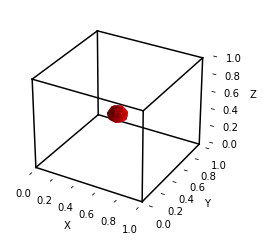

In [12]:
from dftpy.visualize.jupyter import view_density
view_density(mols[0])

In [13]:
ens = []
for i in range(len(ions_list)):
    ions = ions_list[i]
    opt_rho = opt_rhos[i]
    rho_ini = init_rhos[i]
    PSEUDO.restart(grid=grid, ions=ions)
    en_calc = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)
    #print(opt_rho.grid.r)
    energy_new = en_calc.Energy(rho=opt_rho, ions=ions, usePME=False)
    ens.append(energy_new)
    print('ENERGY new', energy_new)
    print('ENERGY init', en_calc.Energy(rho=rho_ini, ions=ions, usePME=False))
print('opt energies', ens)
print('opt energies std', np.std(ens))

L [7.83915089 7.83915089 7.83915089]
Ewald : -4.493063693632152
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.992654992479558
evalfunctional XC
evalfunctional LDA
energy -3.309278543069783
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.392663455669124
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.153205257423746
ENERGY new -15.570229045976998
L [7.83915089 7.83915089 7.83915089]
Ewald : -4.493063693632152
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.4951353816791029
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786334
evalfunctional HARTREE
evalfunctional HARTREE
energy -2.2295844065236952e-33
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.058245823674764885
ENERGY init -4.776842112556918
L [7.83915089 7.83915089 7.83915089]
Ewald : -4.503858764509664
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.989573109233802
evalfunctional XC
evalfunctional LDA
energy -3.3081596927980375
evalfunctional HARTREE
evalfunctional HARTREE
energy 

evalfunctional XC
evalfunctional LDA
energy -1.8371596242786334
evalfunctional HARTREE
evalfunctional HARTREE
energy -2.2295844065236952e-33
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.058245823674764885
ENERGY init -4.776842112556918
L [7.83915089 7.83915089 7.83915089]
Ewald : -4.510241391066939
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.990162479826418
evalfunctional XC
evalfunctional LDA
energy -3.3078457156482655
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.3801537501293
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.12091319630556
ENERGY new -15.568684073065045
L [7.83915089 7.83915089 7.83915089]
Ewald : -4.510241391066939
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.4951353816791029
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786334
evalfunctional HARTREE
evalfunctional HARTREE
energy -2.2295844065236952e-33
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.05824582367476533
ENERGY init -4.794019809991704
L [7.83915

In [54]:
for i in range(1):
    ions = ions_list[i]
    opt_rho = opt_rhos[i]
    rho_ini = init_rhos[i]
    PSEUDO.restart(grid=grid, ions=ions)
    en_calc = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)
    #print(opt_rho.grid.r)
    print('ENERGY new', en_calc.Energy(rho=opt_rho, ions=ions, usePME=False))
    print('ENERGY init', en_calc.Energy(rho=rho_ini, ions=ions, usePME=False))

L [7.83915089 7.83915089 7.83915089]
Ewald : -4.493063693632152
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.992654992479558
evalfunctional XC
evalfunctional LDA
energy -3.309278543069783
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.392663455669124
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.153205257423746
ENERGY new -15.570229045976998
L [7.83915089 7.83915089 7.83915089]
Ewald : -4.493063693632152
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.4951353816791029
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786334
evalfunctional HARTREE
evalfunctional HARTREE
energy -2.2295844065236952e-33
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.058245823674764885
ENERGY init -4.776842112556918


In [16]:
from equiv_dens.utils.grids import CubicalGrid
cube_dim = 20
grid_cl = CubicalGrid(None, nx=cube_dim, ny=cube_dim, nz=cube_dim, origin=[0, 0, 0], extent=np.diag(grid.lattice))
#print(grid_cl.coords)

In [24]:
from equiv_dens.density_functionals.LDA import LDAFunctional
from equiv_dens.utils.base import bohr_to_angstrom
import torch
z_vals = []
for t in data['atom_types']:
    z_vals.append(ions.Zval[t])
z_vals = np.array(z_vals)
print(data['atom_numbers'])
print(z_vals)
lda = LDAFunctional(z_vals, verbose=2)
#print('rho ini', rho_ini)
for i in [0]:
    ions = ions_list[i]
    opt_rho = torch.tensor(opt_rhos[i])
    rho_ini = torch.tensor(init_rhos[i])
    #print('rho tensor', rho)
    pos = torch.tensor(ions.pos)    
    atoms = {}
    atoms['shifted_positions'] = bohr_to_angstrom(pos.unsqueeze(0))
    atoms['ions'] = ions_list[i:i+1]
    atoms['density'] = opt_rho.unsqueeze(0)
    atoms['grid'] = grid_cl
    atoms['dftpy_grid'] = grid
    atoms['pseudo_pot'] = PSEUDO
    print(lda(atoms))
    atoms['density'] = rho_ini.unsqueeze(0)
    print(lda(atoms))

[8 1 1]
[6. 1. 1.]
Ewald real energy tensor([0.1912], dtype=torch.float64)
Ewald corr energy tensor(-18.2354, dtype=torch.float64)
Ewald rec energy tensor([13.5512], dtype=torch.float64)
ewald energy tensor([-4.4931], dtype=torch.float64)
thomas fermi energy tensor([6.9590], dtype=torch.float64)
von weizsacker energy tensor([3.0336], dtype=torch.float64)
tf_vw en tensor([9.9927], dtype=torch.float64)
lda energy tensor([-3.3093], dtype=torch.float64)
hartree energy tensor([6.3927], dtype=torch.float64)
pseudo energy tensor([-24.1532], dtype=torch.float64)
{'shifted_positions': tensor([[[2.0318, 2.0318, 2.0318],
         [3.0011, 1.9296, 2.0318],
         [1.9296, 3.0011, 2.0318]]], dtype=torch.float64), 'ions': [<dftpy.atom.Atom object at 0x7f81ed3dbba8>], 'density': tensor([[[[0.0008, 0.0008, 0.0009,  ..., 0.0009, 0.0008, 0.0008],
          [0.0008, 0.0008, 0.0009,  ..., 0.0009, 0.0008, 0.0008],
          [0.0008, 0.0008, 0.0009,  ..., 0.0010, 0.0009, 0.0008],
          ...,
          

In [25]:
print('integral = ', torch.sum(opt_rho) * grid.dV)

integral =  tensor(8.0000, dtype=torch.float64)


In [19]:
import torch.fft as tfft
opt_rho = torch.tensor(opt_rhos[0])
opt_rho.requires_grad = True
fft_rho = tfft.rfftn(opt_rho)
ss = torch.sum(fft_rho)
ss.backward()
print(opt_rho.grad)
    

tensor([[[ 6.5000e+04, -1.1937e-12,  2.5000e+03,  ..., -9.5967e-13,
           2.5000e+03,  1.0590e-12],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         ...,
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00]],

        [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         ...,
         [ 0.0000e+00,  0

In [28]:
from equiv_dens.data.density_dataset import AtomsDensityData
from functools import partial
from equiv_dens.utils.grids import cubical_grid, cubical_sampling
from equiv_dens.utils.base import bohr_to_angstrom
directory = '2021-01-15_mytHsBse'  # load directory name
model_name = 'mytHsBse'

#directory = '2020-04-30_To0wdEze'
checkpoint_path = os.path.join(
    directory, 'checkpoints')  # checkpoint directory
# load latest checkpoint
checkpoint = torch.load(os.path.join(
    checkpoint_path, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['epoch']
ID = checkpoint['ID']  # load ID
args = checkpoint['args']  # overwrite args
step = checkpoint['step']
args.use_gpu = False
args.load_from = os.path.join(directory, 'best_' + model_name + '.pth')

In [68]:
use_gpu = args.use_gpu and torch.cuda.is_available()
grid_origin = -2.0318
grid_extent = bohr_to_angstrom(np.diag(grid.lattice))
print('extent', grid_extent)
# load dataset(s)
print("loading density from" + args.dens_dataset + "...")
print("loading atoms from" + args.np_dataset + "...")

# density_file = '/home/mihail/data/water_rot/full_densities.hdf5'
# np_file = 'h2o_overlap_static.npy'

#args.num_workers = 0
#args.dens_dataset = 'datasets/h2o_dynamic_pyscf_dft_f_en.npy'

cube_grid_fn = partial(cubical_grid, nx=cube_dim, ny=cube_dim, nz=cube_dim,
                       extent=grid_extent,
                       origin=np.array([grid_origin] * 3))
cube_sampling_fn = cubical_sampling


grid_cl = CubicalGrid(None, nx=cube_dim, ny=cube_dim, nz=cube_dim, origin=[0, 0, 0], extent=np.diag(grid.lattice), dtype=args.dtype)

dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=args.dtype,
                           grid_fn=cube_grid_fn,
                           sampling_fn=cube_sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin)

dataset.add_fixed_properties({'grid': grid_cl, 'dftpy_grid': grid, 'pseudo_pot': PSEUDO})

extent [4.1483003 4.1483003 4.1483003]
loading density fromdatasets/h2o_static_pyscf_dft.npy...
loading atoms fromdatasets/h2o_overlap_static_centered.npy...
Starting atomsdata density init
Some variables
atoms keys dict_keys(['positions', 'hamiltonians', 'overlaps', 'basidef', 'nonzero_indices', 'atom_types', 'atom_numbers', 'energy', 'forces'])
finished init


density shape (8000,)
idx [   7  407  807 1207 1607 2007 2407 2807 3207 3607 4007 4407 4807 5207
 5607 6007 6407 6807 7207 7607   27  427  827 1227 1627 2027 2427 2827
 3227 3627 4027 4427 4827 5227 5627 6027 6427 6827 7227 7627   47  447
  847 1247 1647 2047 2447 2847 3247 3647 4047 4447 4847 5247 5647 6047
 6447 6847 7247 7647   67  467  867 1267 1667 2067 2467 2867 3267 3667
 4067 4467 4867 5267 5667 6067 6467 6867 7267 7667   87  487  887 1287
 1687 2087 2487 2887 3287 3687 4087 4487 4887 5287 5687 6087 6487 6887
 7287 7687  107  507  907 1307 1707 2107 2507 2907 3307 3707 4107 4507
 4907 5307 5707 6107 6507 6907 7307 7707  127  527  927 1327 1727 2127
 2527 2927 3327 3727 4127 4527 4927 5327 5727 6127 6527 6927 7327 7727
  147  547  947 1347 1747 2147 2547 2947 3347 3747 4147 4547 4947 5347
 5747 6147 6547 6947 7347 7747  167  567  967 1367 1767 2167 2567 2967
 3367 3767 4167 4567 4967 5367 5767 6167 6567 6967 7367 7767  187  587
  987 1387 1787 2187 2587 2987 3387 3787 4187 4587 

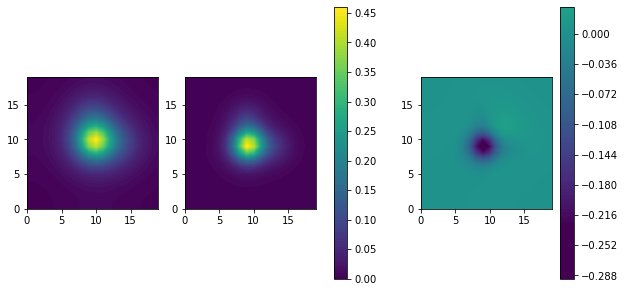

[[3.83954554 3.83954554 3.83954554]
 [5.67121512 3.64632177 3.83954554]
 [3.64632177 5.67121512 3.83954554]]


In [40]:
import matplotlib.pyplot as plt
sample = 0

dens_opt = opt_rhos[sample]
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(131)
dens_opt = np.array(dens_opt)
dens_opt = dens_opt.reshape((cube_dim**3, ))
print('density shape', dens_opt.shape)
x, y  = np.meshgrid(np.arange(cube_dim), np.arange(cube_dim))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 7
idx = np.ravel_multi_index((x_f, y_f, z_f), (cube_dim, cube_dim, cube_dim))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens_opt[idx]
dens2d = dens2d.reshape(cube_dim, cube_dim)

indices = np.stack((x_f, y_f, z_f), axis=1)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

dens_data = np.array(dataset[sample]['density'].squeeze())
print('density shape', dens_data.shape)

ax2 = fig.add_subplot(132)
print('idx', idx)
densd2d = dens_data[idx]
densd2d = densd2d.reshape(cube_dim, cube_dim)

vmin = np.min(densd2d)
vmax = np.max(densd2d)
c2 = ax2.contourf(x, y, densd2d, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, dens2d-densd2d, vmin=-vmax/2, vmax=vmax/2, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
plt.show()
print(ions_list[sample].pos)

In [47]:
for i in range(len(opt_rhos)):
    data_sample = dataset[i]
    dens_opt = torch.tensor(opt_rhos[i]).view(1,-1)
    dens_data = data_sample['density']
    diff = torch.sum(torch.abs(dens_data - dens_opt) * data_sample['coord_weights'])
    err = diff / torch.sum(dens_data * data_sample['coord_weights'])
    print('int data', torch.sum(dens_data * data_sample['coord_weights']))
    print('int opt', torch.sum(dens_opt * data_sample['coord_weights']))
    print('err', err)

int data tensor(7.8232)
int opt tensor(8.0000, dtype=torch.float64)
err tensor(0.6350, dtype=torch.float64)
int data tensor(7.8222)
int opt tensor(8.0000, dtype=torch.float64)
err tensor(0.6329, dtype=torch.float64)
int data tensor(7.8232)
int opt tensor(8.0000, dtype=torch.float64)
err tensor(0.6350, dtype=torch.float64)
int data tensor(7.8232)
int opt tensor(8.0000, dtype=torch.float64)
err tensor(0.6350, dtype=torch.float64)
int data tensor(7.8238)
int opt tensor(8.0000, dtype=torch.float64)
err tensor(0.6319, dtype=torch.float64)
int data tensor(7.8239)
int opt tensor(8.0000, dtype=torch.float64)
err tensor(0.6298, dtype=torch.float64)
int data tensor(7.8232)
int opt tensor(8.0000, dtype=torch.float64)
err tensor(0.6350, dtype=torch.float64)
int data tensor(7.8231)
int opt tensor(8.0000, dtype=torch.float64)
err tensor(0.6320, dtype=torch.float64)
int data tensor(7.8253)
int opt tensor(8.0000, dtype=torch.float64)
err tensor(0.6287, dtype=torch.float64)
int data tensor(7.8232)
int 

In [41]:
)

[[ 0.          0.          0.        ]
 [ 0.9692778  -0.10224961  0.        ]
 [-0.10224961  0.9692778   0.        ]]


pseudo shape (8000,)
idx [   7  407  807 1207 1607 2007 2407 2807 3207 3607 4007 4407 4807 5207
 5607 6007 6407 6807 7207 7607   27  427  827 1227 1627 2027 2427 2827
 3227 3627 4027 4427 4827 5227 5627 6027 6427 6827 7227 7627   47  447
  847 1247 1647 2047 2447 2847 3247 3647 4047 4447 4847 5247 5647 6047
 6447 6847 7247 7647   67  467  867 1267 1667 2067 2467 2867 3267 3667
 4067 4467 4867 5267 5667 6067 6467 6867 7267 7667   87  487  887 1287
 1687 2087 2487 2887 3287 3687 4087 4487 4887 5287 5687 6087 6487 6887
 7287 7687  107  507  907 1307 1707 2107 2507 2907 3307 3707 4107 4507
 4907 5307 5707 6107 6507 6907 7307 7707  127  527  927 1327 1727 2127
 2527 2927 3327 3727 4127 4527 4927 5327 5727 6127 6527 6927 7327 7727
  147  547  947 1347 1747 2147 2547 2947 3347 3747 4147 4547 4947 5347
 5747 6147 6547 6947 7347 7747  167  567  967 1367 1767 2167 2567 2967
 3367 3767 4167 4567 4967 5367 5767 6167 6567 6967 7367 7767  187  587
  987 1387 1787 2187 2587 2987 3387 3787 4187 4587 4

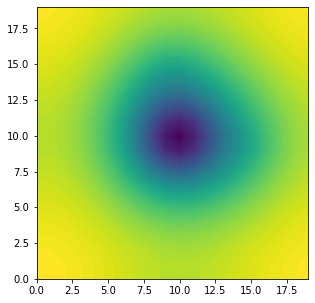

In [50]:
from equiv_dens.utils.grids import CubicalGrid

PSEUDO.restart(grid=grid, ions=ions_list[sample])
dens = opt_rhos[5]
PSEUDO(dens)
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
pot = np.array(PSEUDO.vreal)
pot = pot.reshape((cube_dim**3, ))
print('pseudo shape', pot.shape)
x, y  = np.meshgrid(np.arange(cube_dim), np.arange(cube_dim))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 7
idx = np.ravel_multi_index((x_f, y_f, z_f), (cube_dim, cube_dim, cube_dim))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
pot2d = pot[idx]
pot2d = pot2d.reshape(cube_dim, cube_dim)

indices = np.stack((x_f, y_f, z_f), axis=1)
vmin = np.min(pot2d)
vmax = np.max(pot2d)
c1 = ax1.contourf(x, y, pot2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

In [69]:
from equiv_dens.nn.dft_network import DFTNetwork
from equiv_dens.nn.representation.spherical_harmonic import EquivariantSphericalHarmonics
from equiv_dens.nn.property_output.density import DensityCoeffsNetwork, DensityExpansion
from equiv_dens.nn.modules.clebsch_gordan import ClebschGordanMatrix
from equiv_dens.density_functionals.LDA import LDAFunctional
import torch.nn as nn

clebsch_gordan = ClebschGordanMatrix()
repr_model = EquivariantSphericalHarmonics(
    orbitals=dataset.orbitals,
    order=args.order,
    num_features=args.num_features,
    num_basis_functions=args.num_basis_functions,
    num_modules=args.num_modules,
    num_residual_pre_x=args.num_residual_pre_x,
    num_residual_post_x=args.num_residual_post_x,
    num_residual_pre_vi=args.num_residual_pre_vi,
    num_residual_pre_vj=args.num_residual_pre_vj,
    num_residual_post_v=args.num_residual_post_v,
    num_residual_output=args.num_residual_output,
    num_radial_components=args.num_radial_components,
    basis_functions=args.basis_functions,
    cutoff=args.cutoff,
    activation=args.activation,
    clebsch_gordan=clebsch_gordan,
)
dens_model = DensityCoeffsNetwork(
    orbitals=dataset.orbitals,
    order=args.order,
    num_features=args.num_features,
    positive_coeffs=args.positive_coeffs,
    clebsch_gordan=clebsch_gordan,
    verbose=args.verbose)

expansion_model = DensityExpansion(dataset.orbitals, radial_coeffs=dataset.radial_coeffs,
                                   expansion_constraint=args.expansion_constraint,
                                   integral_constraint=args.integral_constraint,
                                   verbose=args.verbose,
                                   softmax_norm=args.softmax_norm)

dataset[0]['pseudo_pot'].restart(grid=dataset[0]['dftpy_grid'], ions=dataset.ions[0])
z_vals = []
print('ions0', dataset.ions[0])
for t in dataset.atoms['atom_types']:
    z_vals.append(dataset.ions[0].Zval[t])
z_vals = np.array(z_vals)
print(dataset.atoms['atom_numbers'])
print(z_vals)
functional = LDAFunctional(z_vals, verbose=args.verbose, energy_offset=args.energy_offset, store_energy=(args.energy_model is None))

density_model = nn.Sequential(repr_model, dens_model)

functional_en_model = nn.Sequential(expansion_model, functional)

property_models = {}
calculate_forces_dict = {}
property_models['energy_min'] = functional_en_model
calculate_forces_dict['energy_min'] = False

print('property models', property_models)
model = DFTNetwork(density_model, property_models, calculate_forces_dict=calculate_forces_dict, verbose=args.verbose)
model.load_state_dict(torch.load(args.load_from, map_location='cpu'))
model.to(args.dtype)

cg_matrix shape torch.Size([121, 121, 121])
orbital_spec [[(8, 11, 0), (8, 8, 1), (8, 6, 2), (8, 4, 3), (8, 3, 4), (8, 2, 5)], [(1, 5, 0), (1, 4, 1), (1, 4, 2), (1, 3, 3), (1, 2, 4)], [(1, 5, 0), (1, 4, 1), (1, 4, 2), (1, 3, 3), (1, 2, 4)]]
L_counts [16, 12, 10, 7, 5, 2, 0, 0, 0, 0, 0, 0, 0]
L_dict {(8, 0): range(0, 11), (8, 1): range(0, 8), (8, 2): range(0, 6), (8, 3): range(0, 4), (8, 4): range(0, 3), (8, 5): range(0, 2), (1, 0): range(11, 16), (1, 1): range(8, 12), (1, 2): range(6, 10), (1, 3): range(4, 7), (1, 4): range(3, 5)}
max lcounts 16
ions0                 Zval : {'H': 1.0, 'C': 4.0, 'O': 6.0}
                 pos : [[3.8395456  3.8395456  3.8395456 ]
 [5.67121529 3.64632182 3.8395456 ]
 [3.64632182 5.67121529 3.8395456 ]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
[8 1 1]
[6. 1. 1.]
property models {'energy_min': Sequential(
  (0): DensityExpansion()
  (1): LDAFunctional(
    (ewald): Ewald()
  )
)}


DFTNetwork(
  (density_repr_model): Sequential(
    (0): EquivariantSphericalHarmonics(
      (clebsch_gordan): ClebschGordanMatrix()
      (embedding): SphericalEmbedding(
        (embedding): Embedding(
          (config_linear): Linear(in_features=16, out_features=128, bias=False)
        )
      )
      (radial_basis_functions): ExponentialBernsteinRadialBasisFunctions()
      (module): ModuleList(
        (0): ModularBlock(
          (interaction): InteractionBlock(
            (activation_i): Swish()
            (activation_j): Swish()
            (activation_v): Swish()
            (angular_fn1): SphericalLinear(
              (linear): ModuleList(
                (0): Linear(in_features=1, out_features=128, bias=True)
                (1): Linear(in_features=1, out_features=128, bias=False)
                (2): Linear(in_features=1, out_features=128, bias=False)
                (3): Linear(in_features=1, out_features=128, bias=False)
                (4): Linear(in_features=1, ou

data dtype torch.float32
density shape (8000,)
idx [   7  407  807 1207 1607 2007 2407 2807 3207 3607 4007 4407 4807 5207
 5607 6007 6407 6807 7207 7607   27  427  827 1227 1627 2027 2427 2827
 3227 3627 4027 4427 4827 5227 5627 6027 6427 6827 7227 7627   47  447
  847 1247 1647 2047 2447 2847 3247 3647 4047 4447 4847 5247 5647 6047
 6447 6847 7247 7647   67  467  867 1267 1667 2067 2467 2867 3267 3667
 4067 4467 4867 5267 5667 6067 6467 6867 7267 7667   87  487  887 1287
 1687 2087 2487 2887 3287 3687 4087 4487 4887 5287 5687 6087 6487 6887
 7287 7687  107  507  907 1307 1707 2107 2507 2907 3307 3707 4107 4507
 4907 5307 5707 6107 6507 6907 7307 7707  127  527  927 1327 1727 2127
 2527 2927 3327 3727 4127 4527 4927 5327 5727 6127 6527 6927 7327 7727
  147  547  947 1347 1747 2147 2547 2947 3347 3747 4147 4547 4947 5347
 5747 6147 6547 6947 7347 7747  167  567  967 1367 1767 2167 2567 2967
 3367 3767 4167 4567 4967 5367 5767 6167 6567 6967 7367 7767  187  587
  987 1387 1787 2187 2587 

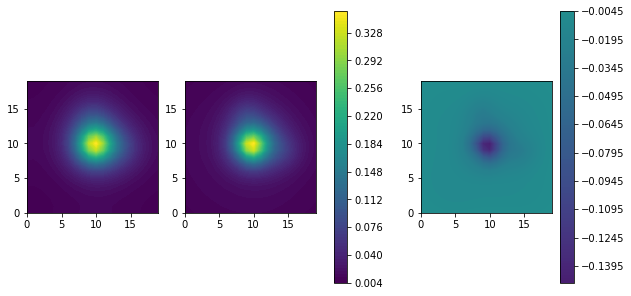

[[3.83954554 3.83954554 3.83954554]
 [5.67121512 3.64632177 3.83954554]
 [3.64632177 5.67121512 3.83954554]]


In [80]:
import matplotlib.pyplot as plt
sample = 0

print('data dtype', args.dtype)
dens_opt = opt_rhos[sample]
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(131)
dens_opt = np.array(dens_opt)
dens_opt = dens_opt.reshape((cube_dim**3, ))
print('density shape', dens_opt.shape)
x, y  = np.meshgrid(np.arange(cube_dim), np.arange(cube_dim))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 7
idx = np.ravel_multi_index((x_f, y_f, z_f), (cube_dim, cube_dim, cube_dim))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens_opt[idx]
dens2d = dens2d.reshape(cube_dim, cube_dim)

indices = np.stack((x_f, y_f, z_f), axis=1)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

data_sample = dataset[sample]
model_pred = model(data_sample)

dens_pred = np.array(model_pred['density'].squeeze().detach().cpu())
print('density shape', dens_pred.shape)

ax2 = fig.add_subplot(132)
print('idx', idx)
densp2d = dens_pred[idx]
densp2d = densp2d.reshape(cube_dim, cube_dim)

vmin = np.min(densp2d)
vmax = np.max(densp2d)
c2 = ax2.contourf(x, y, densp2d, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, dens2d-densp2d, vmin=-vmax/2, vmax=vmax/2, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
plt.savefig('figures/functional_vs_pred_dens.pdf', dpi=300)
plt.show()
print(ions_list[sample].pos)

In [78]:
for i in range(len(opt_rhos)):
    data_sample = dataset[i]
    dens_opt = torch.tensor(opt_rhos[i]).view(1,-1)
    dens_pred = model(data_sample)['density']
    diff = torch.sum(torch.abs(dens_pred - dens_opt) * data_sample['coord_weights'])
    err = diff / torch.sum(dens_pred * data_sample['coord_weights'])
    print('int data', torch.sum(dens_pred * data_sample['coord_weights']))
    print('int opt', torch.sum(dens_opt * data_sample['coord_weights']))
    print('err', err)

int data tensor(11.8989, grad_fn=<SumBackward0>)
int opt tensor(8.0000, dtype=torch.float64)
err tensor(0.3844, dtype=torch.float64, grad_fn=<DivBackward0>)
int data tensor(11.9028, grad_fn=<SumBackward0>)
int opt tensor(8.0000, dtype=torch.float64)
err tensor(0.3532, dtype=torch.float64, grad_fn=<DivBackward0>)
int data tensor(11.8989, grad_fn=<SumBackward0>)
int opt tensor(8.0000, dtype=torch.float64)
err tensor(0.3844, dtype=torch.float64, grad_fn=<DivBackward0>)
int data tensor(11.8989, grad_fn=<SumBackward0>)
int opt tensor(8.0000, dtype=torch.float64)
err tensor(0.3844, dtype=torch.float64, grad_fn=<DivBackward0>)
int data tensor(11.9063, grad_fn=<SumBackward0>)
int opt tensor(8.0000, dtype=torch.float64)
err tensor(0.3814, dtype=torch.float64, grad_fn=<DivBackward0>)
int data tensor(11.9084, grad_fn=<SumBackward0>)
int opt tensor(8.0000, dtype=torch.float64)
err tensor(0.3807, dtype=torch.float64, grad_fn=<DivBackward0>)
int data tensor(11.8989, grad_fn=<SumBackward0>)
int opt t